In [1]:
# 02_retention_logistic_regression.ipynb
# Business Question: What predicts retention and how strong are the effects?


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Data generation
np.random.seed(1)
n = 250
training_hours = np.random.normal(15, 5, n)
manager_1on1 = np.random.normal(2, 1, n)
peer_collab = np.random.normal(6, 2, n)
psych_safety = 0.4*manager_1on1 + 0.5*peer_collab + np.random.normal(3,1,n)
performance = 0.3*training_hours + 0.6*psych_safety + np.random.normal(50,10,n)
retention_prob = 1 / (1 + np.exp(-(0.05*performance + 0.8*psych_safety - 5)))
retention = np.random.binomial(1, retention_prob)

df2 = pd.DataFrame({
    "TrainingHours": training_hours,
    "Manager1on1": manager_1on1,
    "PeerCollab": peer_collab,
    "PsychSafety": psych_safety,
    "Performance": performance,
    "Retention": retention
})

print(df2.head())
print("\nRetention rate:", df2['Retention'].mean())


   TrainingHours  Manager1on1  PeerCollab  PsychSafety  Performance  Retention
0      23.121727     1.655013    2.561211     6.479147    59.291645          1
1      11.941218     1.769160    6.114242     6.764410    33.315926          1
2      12.359141    -0.793085    4.400905     6.176768    62.493647          1
3       9.635157     3.937529    5.416811     6.844419    53.756875          1
4      19.327038     2.366332    5.482034     7.277589    45.053899          0

Retention rate: 0.884


In [2]:
# Logistic regression
X = df2[["TrainingHours", "PsychSafety", "Performance"]]
X = sm.add_constant(X)
y = df2["Retention"]
logit_model = sm.Logit(y, X).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.273981
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              Retention   No. Observations:                  250
Model:                          Logit   Df Residuals:                      246
Method:                           MLE   Df Model:                            3
Date:                Wed, 04 Feb 2026   Pseudo R-squ.:                  0.2366
Time:                        16:15:27   Log-Likelihood:                -68.495
converged:                       True   LL-Null:                       -89.720
Covariance Type:            nonrobust   LLR p-value:                 3.222e-09
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -5.5470      1.660     -3.342      0.001      -8.800      -2.294
TrainingHours     0.

In [3]:
# Odds ratios for business interpretation
odds_ratios = np.exp(logit_model.params)
print("\nOdds Ratios:")
for var, ratio in odds_ratios.items():
    print(f"{var}: {ratio:.3f}")


Odds Ratios:
const: 0.004
TrainingHours: 1.023
PsychSafety: 2.656
Performance: 1.021


In [4]:
# Model predictions and evaluation
y_pred_prob = logit_model.predict(X)
y_pred_class = (y_pred_prob > 0.5).astype(int)
print("Accuracy:", accuracy_score(y, y_pred_class))
print("\nConfusion Matrix:")
print(confusion_matrix(y, y_pred_class))
print("\nClassification Report:")
print(classification_report(y, y_pred_class))

Accuracy: 0.908

Confusion Matrix:
[[  8  21]
 [  2 219]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.28      0.41        29
           1       0.91      0.99      0.95       221

    accuracy                           0.91       250
   macro avg       0.86      0.63      0.68       250
weighted avg       0.90      0.91      0.89       250



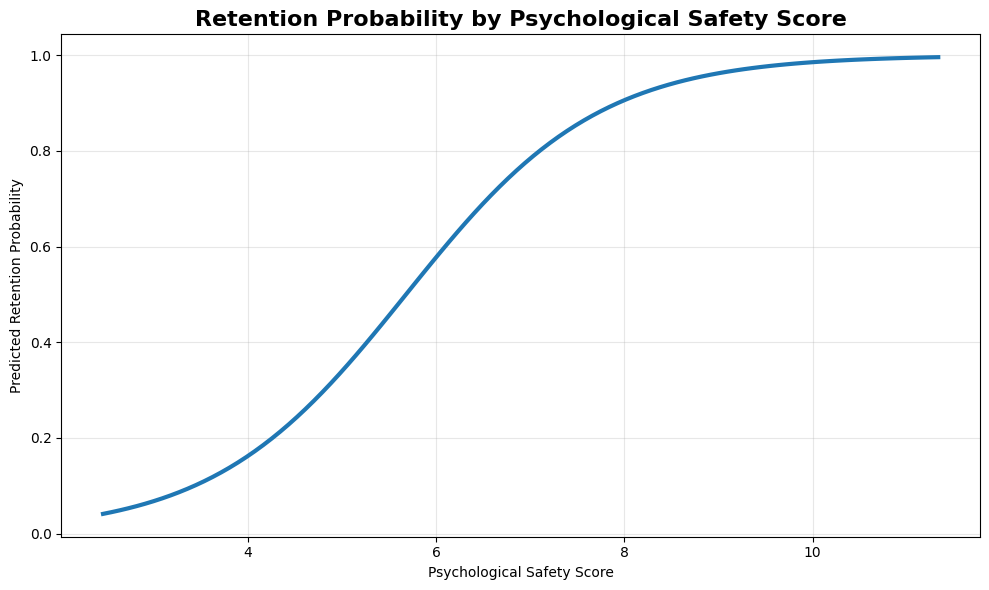

In [5]:
# Retention probability curve (PsychSafety)
plt.figure(figsize=(10, 6))
x_vals = np.linspace(df2["PsychSafety"].min(), df2["PsychSafety"].max(), 100)
log_odds = logit_model.params["const"] + logit_model.params["PsychSafety"] * x_vals
probabilities = 1 / (1 + np.exp(-log_odds))
plt.plot(x_vals, probabilities, linewidth=3)
plt.title("Retention Probability by Psychological Safety Score", fontsize=16, fontweight='bold')
plt.xlabel("Psychological Safety Score")
plt.ylabel("Predicted Retention Probability")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../visuals/retention_probability_curve.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
# Save data
df2.to_csv('../data/retention_dataset.csv', index=False)